In [10]:
import os
# 设置环境变量以避免内存泄漏警告
os.environ["OMP_NUM_THREADS"] = "1"

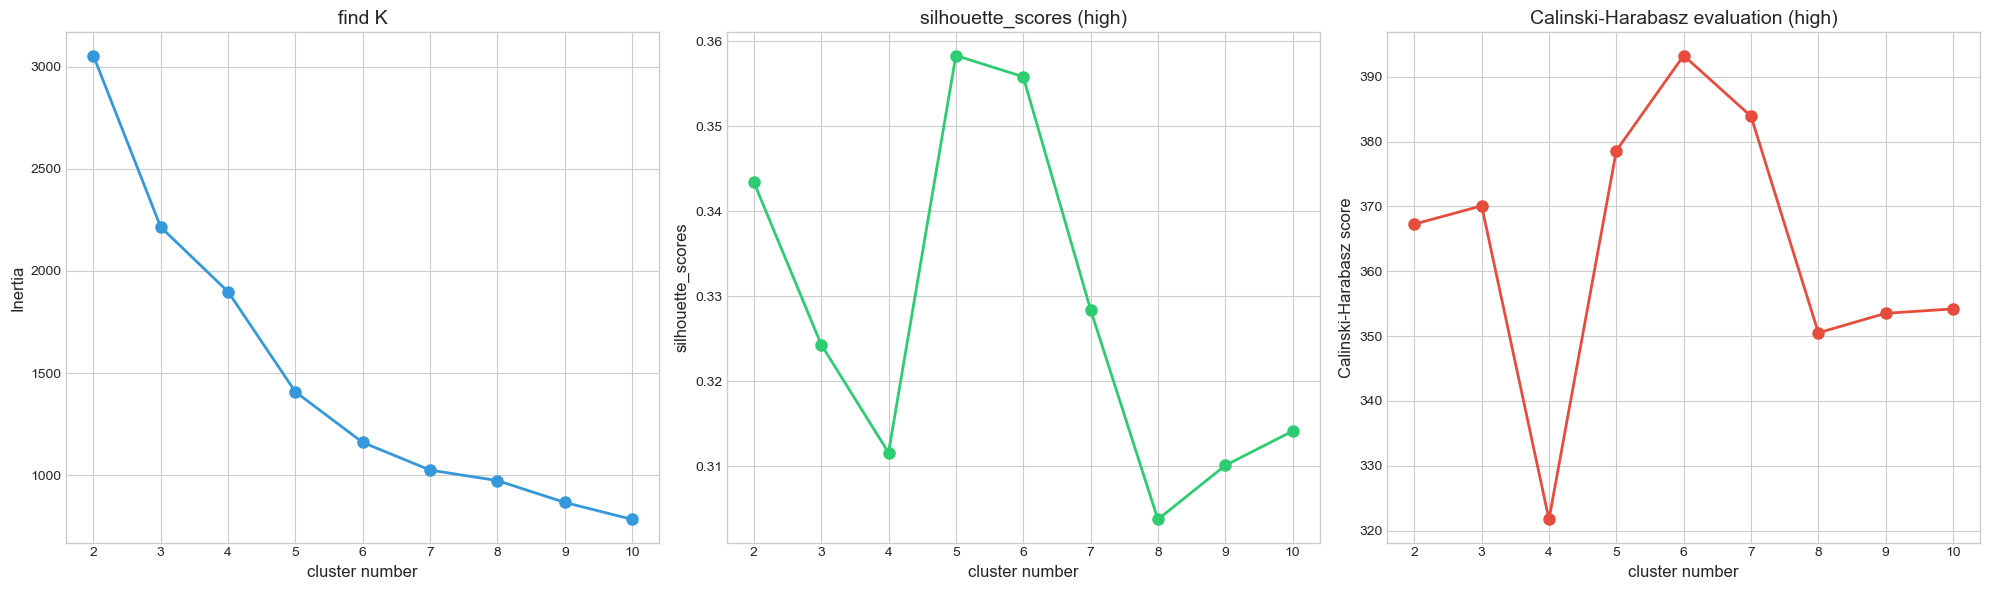

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.cm as cm
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
plt.style.use('seaborn-v0_8-whitegrid')           # 使用更现代的绘图风格

df = pd.read_csv("class_2.csv")
features = ['Ar', 'VE', 'EN', 'BP', 'Co']
X1 = df[features].to_numpy()
y = df.iloc[:, -1].to_numpy()
X=np.vstack((X1[:,0]/100,X1[:,1],X1[:,2],X1[:,3]/925,X1[:,4])).T  


# 确定最佳聚类数 (使用肘部法则)
inertia = []
silhouette_scores = []
ch_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, cluster_labels))
    ch_scores.append(calinski_harabasz_score(X, cluster_labels))

# 创建一个包含三个子图的图表来评估最佳聚类数
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 绘制肘部图
axes[0].plot(k_range, inertia, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].set_xlabel('cluster number', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('find K', fontsize=14)
axes[0].grid(True)

# 绘制轮廓系数图 (越高越好)
axes[1].plot(k_range, silhouette_scores, 'o-', color='#2ecc71', linewidth=2, markersize=8)
axes[1].set_xlabel('cluster number', fontsize=12)
axes[1].set_ylabel('silhouette_scores', fontsize=12)
axes[1].set_title('silhouette_scores (high)', fontsize=14)
axes[1].grid(True)

# 绘制CH得分图 (越高越好)
axes[2].plot(k_range, ch_scores, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[2].set_xlabel('cluster number', fontsize=12)
axes[2].set_ylabel('Calinski-Harabasz score', fontsize=12)
axes[2].set_title('Calinski-Harabasz evaluation (high)', fontsize=14)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('cluster evaluation.png', dpi=300, bbox_inches='tight')
plt.show()




每个聚类的数据点数量:
cluster
0    126
1     96
2     22
3    111
4     28
5     30
6     95
7     61
8     52
Name: count, dtype: int64

PCA主成分解释的方差比例: [0.94853556 0.05146216]
累计解释的方差比例: 1.0000

PCA成分与原始特征的关系:
                   Ar        VE        EN        BP        Co
Component 1  0.114216 -0.000462  0.000170  0.993454  0.001702
Component 2  0.993451  0.003008  0.000157 -0.114213 -0.000636


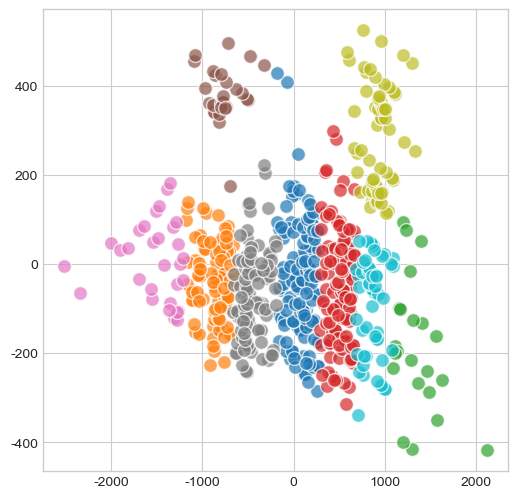

In [29]:
# 根据评估选择适当的聚类数 (根据上面图表结果选择)
# 这里假设最佳聚类数为3，您可以根据上面的评估结果修改
k = 9
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
df['cluster'] = cluster_labels

# 打印每个聚类的基本统计信息
print("\n每个聚类的数据点数量:")
cluster_counts = df['cluster'].value_counts().sort_index()
print(cluster_counts)

# 使用PCA将数据降至2维以便可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 解释PCA主成分
explained_variance = pca.explained_variance_ratio_
print(f"\nPCA主成分解释的方差比例: {explained_variance}")
print(f"累计解释的方差比例: {sum(explained_variance):.4f}")

# 查看PCA成分与原始特征的关系
pca_components = pd.DataFrame(
    pca.components_, 
    columns=features,
    index=['Component 1', 'Component 2']
)
print("\nPCA成分与原始特征的关系:")
print(pca_components)

# 更美观的聚类可视化
plt.figure(figsize=(6, 6))
colors = cm.tab10(np.linspace(0, 1, k))

# 添加散点图（带有透明度和更大的点）
for i in range(k):
    plt.scatter(
        X_pca[df['cluster'] == i, 0],
        X_pca[df['cluster'] == i, 1],
        s=100,  # 点的大小
        c=[colors[i]],  # 使用特定颜色
        label=f'聚类 {i} ({cluster_counts[i]} 个样本)',
        alpha=0.7,  # 透明度
        edgecolors='w'  # 白色边缘
    )
plt.savefig(f'{k}cluster.png', dpi=300, bbox_inches='tight')



每个聚类的数据点数量:
cluster
0    102
1     97
2     38
3     32
4     95
5    117
6    101
7     33
8      6
Name: count, dtype: int64


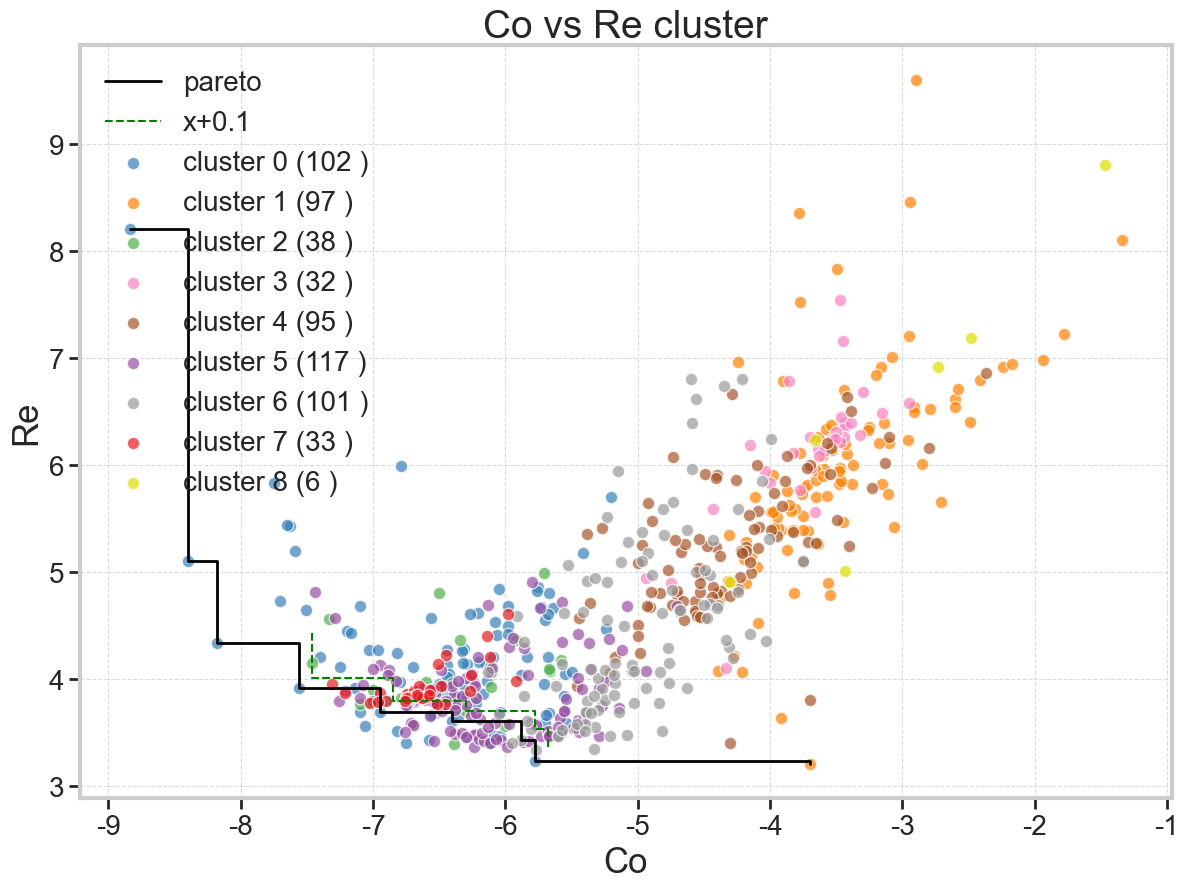

In [30]:
import os
# 设置环境变量以避免内存泄漏警告
os.environ["OMP_NUM_THREADS"] = "3"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.cm as cm
import seaborn as sns

# 检测系统类型并设置合适的中文字体
system = platform.system()

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.style.use('seaborn-v0_8-whitegrid')  # 新版本


# 读取数据
df = pd.read_csv("class_2.csv")
features = ['Ar', 'VE', 'EN', 'BP', 'Co']
X = df[features].to_numpy()
X_scaled =np.vstack((X[:,0]/100,X[:,1],X[:,2],X[:,3]/925,X[:,4])).T  
# 保存原始索引
df['original_index'] = df.index

# 确定最佳聚类数 (使用多种评估方法)
inertia = []

k = 9
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels

# 打印每个聚类的基本统计信息
print("\n每个聚类的数据点数量:")
cluster_counts = df['cluster'].value_counts().sort_index()
print(cluster_counts)
df.to_csv('class_2_with_clusters.csv', index=False)


df1 = pd.read_csv("class_2_with_clusters.csv")
df1['original_index'] = df1.index  # 保存原始索引以便追踪
X1 = df1.iloc[:,[8]]
y1= df1.iloc[:,[9]] 
clusters = df1['cluster'].unique()

x_col = 'Co'
y_col = 'Re' 
colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628','#984ea3', '#999999', '#e41a1c','#dede00']
plt.figure(figsize=(12, 9))
ax = plt.gca()  # 获取当前轴对象
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_linewidth(3)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
pareto = np.loadtxt('pareto', delimiter=',')
shifted_y = pareto[5:15, 1] + 0.1
plt.plot(pareto[:,0],pareto[:,1],c='k',linewidth=2,label='pareto')
plt.plot(pareto[5:15, 0]+0.1, shifted_y, c='g', linestyle='--', linewidth=1.5, label='x+0.1')# 绘制y+0.1的新前沿
for i, cluster_id in enumerate(sorted(clusters)):
    # 创建当前聚类的掩码
    mask = df1['cluster'] == cluster_id
    
    # 根据掩码选择x和y的值
    x_values = -df1.loc[mask, x_col]
    y_values = df1.loc[mask, y_col]
    
    # 绘制当前聚类的散点图
    plt.scatter(
        x_values, y_values, 
        color=colors[i], 
        s=80,  # 点的大小
        alpha=0.7,  # 透明度
        edgecolors='w',  # 白色边缘
        label=f'cluster {cluster_id} ({sum(mask)} )'
    )

# 添加标题和标签
plt.title(f'{x_col} vs {y_col} cluster', fontsize=28)
plt.xlabel(x_col, fontsize=25)
plt.ylabel(y_col, fontsize=25)
plt.legend(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'cluster_{x_col}_vs_{y_col}{k}.png', dpi=300, bbox_inches='tight')
plt.show()

